In [1]:
#model.py
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.skip = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.skip(x)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += identity
        return F.relu(out)


class ColorDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(64, 64, kernel_size=1)

    def forward(self, x):
        return F.relu(self.conv(x))


class GridMaxModel(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.layer1 = ResidualBlock(32, 64, stride=2)
        self.layer2 = ResidualBlock(64, 64)

        self.color_detector = ColorDetector()

        self.pool = nn.AdaptiveAvgPool2d((3, 3))
        self.classifier = nn.Linear(64 * 3 * 3, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.color_detector(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

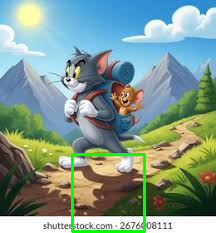

In [10]:
import cv2
import torch
from torchvision import transforms
from google.colab.patches import cv2_imshow
#from model import GridMaxModel


def index_to_grid(idx):
    return idx // 3, idx % 3


def draw_predicted_region(image, idx, confidence=None):
    h, w, _ = image.shape

    grid_h = h // 3
    grid_w = w // 3

    i, j = index_to_grid(idx)

    y1, y2 = i * grid_h, (i + 1) * grid_h
    x1, x2 = j * grid_w, (j + 1) * grid_w

    output = image.copy()

    thickness = int(2 + (confidence or 0) * 3)
    cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), thickness)

    return output


def run_inference(image_path, model):
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    tensor = transform(image_rgb).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)

        idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, idx].item()

    output = draw_predicted_region(image, idx, confidence)

    return output


if __name__ == "__main__":
    model = GridMaxModel()
    model.load_state_dict(torch.load("grid_model.pth", map_location="cpu"))

    output = run_inference("TomNJerry_test3.jpg", model)

    cv2_imshow( output)
    cv2.waitKey(0)

In [5]:
#train.py
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim

#from model import GridMaxModel


# =========================================================
# Dataset (Auto-label based on max intensity region)
# =========================================================
class GridDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_paths = [
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.endswith((".jpg", ".png", ".jpeg"))
        ]
        self.transform = transform

    def get_label(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        h, w = gray.shape
        grid_h = h // 3
        grid_w = w // 3

        max_val = -1
        max_idx = 0

        for i in range(3):
            for j in range(3):
                region = gray[
                    i * grid_h:(i + 1) * grid_h,
                    j * grid_w:(j + 1) * grid_w
                ]

                val = np.mean(region)
                idx = i * 3 + j

                if val > max_val:
                    max_val = val
                    max_idx = idx

        return max_idx

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])

        label = self.get_label(image)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


# =========================================================
# Training Function
# =========================================================
def train(model, dataloader, device, epochs=10):
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)  # (B, 9)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Accuracy
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        acc = correct / total * 100

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {total_loss:.4f} | Accuracy: {acc:.2f}%")


# =========================================================
# Main
# =========================================================
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    dataset = GridDataset("dataset/images", transform=transform)

    dataloader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=True,
        num_workers=2
    )

    model = GridMaxModel()

    train(model, dataloader, device, epochs=10)

    torch.save(model.state_dict(), "grid_model.pth")
    print("Model saved as grid_model.pth")


# =========================================================
# Run
# =========================================================
if __name__ == "__main__":
    main()

Epoch [1/10] Loss: 2.2384 | Accuracy: 0.00%
Epoch [2/10] Loss: 1.5986 | Accuracy: 80.00%
Epoch [3/10] Loss: 1.1882 | Accuracy: 100.00%
Epoch [4/10] Loss: 0.8917 | Accuracy: 100.00%
Epoch [5/10] Loss: 0.6656 | Accuracy: 100.00%
Epoch [6/10] Loss: 0.4882 | Accuracy: 100.00%
Epoch [7/10] Loss: 0.3517 | Accuracy: 100.00%
Epoch [8/10] Loss: 0.2494 | Accuracy: 100.00%
Epoch [9/10] Loss: 0.1732 | Accuracy: 100.00%
Epoch [10/10] Loss: 0.1191 | Accuracy: 100.00%
Model saved as grid_model.pth


In [ ]:
from google.colab import drive
drive.mount('/content/drive')